In [5]:
import re, os
import pandas as pd
import numpy as np

# ONLY use this folder to avoid duplicates
ENROLL_DIR = "./Medicare-Advantage/data/input/ma/enrollment"

enroll_zips = sorted(find_files("CPSC-Enrollment-*.zip"))
enroll_zips = [z for z in enroll_zips if z.startswith(ENROLL_DIR)]

# ONLY Jan 2010–2015 (6 files)
enroll_zips = [z for z in enroll_zips if re.search(r"CPSC-Enrollment-(2010|2011|2012|2013|2014|2015)-01\.zip$", z)]

print("Enrollment zips (should be 6):", len(enroll_zips))
print(enroll_zips)

Enrollment zips (should be 6): 6
['./Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2010-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2011-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2012-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2013-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2014-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2015-01.zip']


In [6]:
enroll_zips_all = sorted(find_files("CPSC-Enrollment-*.zip"))

# only 2010-2015 JANUARY files (6 files total)
enroll_zips = [z for z in enroll_zips_all if re.search(r"CPSC-Enrollment-(2010|2011|2012|2013|2014|2015)-01\.zip$", z)]

print("January-only zips:", len(enroll_zips))
print(enroll_zips[:10])

January-only zips: 12
['./Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2010-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2011-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2012-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2013-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2014-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2015-01.zip', './Medicare-Advantage/ma-data/ma/enrollment/CPSC-Enrollment-2010-01.zip', './Medicare-Advantage/ma-data/ma/enrollment/CPSC-Enrollment-2011-01.zip', './Medicare-Advantage/ma-data/ma/enrollment/CPSC-Enrollment-2012-01.zip', './Medicare-Advantage/ma-data/ma/enrollment/CPSC-Enrollment-2013-01.zip']


In [7]:
dfs = []
for z in enroll_zips:
    d = read_one_enrollment_zip(z)
    if d is None:
        continue
    d["__source_zip"] = os.path.basename(z)
    d["year"] = int(re.search(r"CPSC-Enrollment-(\d{4})-", os.path.basename(z)).group(1))
    dfs.append(d)

enroll = pd.concat(dfs, ignore_index=True)

# Rename known columns
enroll = enroll.rename(columns={
    "Contract ID": "contract_id",
    "Plan ID": "plan_id",
    "Enrollment": "enroll",
    "Plan Type": "plan_type",
    "Offers Part D": "partd",
})

# Clean types
enroll["contract_id"] = enroll["contract_id"].astype(str).str.strip()

# plan_id sometimes reads float; keep as Int64 (nullable)
enroll["plan_id"] = pd.to_numeric(enroll["plan_id"], errors="coerce").astype("Int64")

# enrollment often has commas or weird stuff
enroll["enroll"] = (
    enroll["enroll"].astype(str)
    .str.replace(",", "", regex=False)
    .replace({"nan": np.nan, "": np.nan})
)
enroll["enroll"] = pd.to_numeric(enroll["enroll"], errors="coerce")

# drop junk rows
enroll = enroll.dropna(subset=["contract_id", "plan_id", "enroll"])

# market share per year
enroll["mkt_share"] = enroll["enroll"] / enroll.groupby("year")["enroll"].transform("sum")

enroll = enroll[["year","contract_id","plan_id","enroll","mkt_share","plan_type","partd"]].copy()

print("enroll shape:", enroll.shape)
print(enroll.groupby("year").size())
print(enroll.head())

enroll shape: (448822, 7)
year
2011    217840
2012    230982
dtype: int64
      year contract_id  plan_id  enroll     mkt_share plan_type partd
6627  2011         nan      801    52.0  8.903010e-07       NaN   NaN
6628  2011         nan      801    18.0  3.081811e-07       NaN   NaN
6694  2011         nan      801    25.0  4.280293e-07       NaN   NaN
6697  2011         nan      801    20.0  3.424234e-07       NaN   NaN
6706  2011         nan      801    12.0  2.054541e-07       NaN   NaN


In [11]:
import glob, os, re, zipfile
import pandas as pd
import numpy as np

# ---------- 1) Rebuild enroll_zips (ONLY 2010-2015 January, ONLY data/input folder) ----------
BASE = "."  # adjust only if your notebook is not run from where Medicare-Advantage is visible

def find_files(pattern):
    return glob.glob(os.path.join(BASE, "**", pattern), recursive=True)

ENROLL_DIR = "./Medicare-Advantage/data/input/ma/enrollment"

enroll_zips = sorted(find_files("CPSC-Enrollment-201*-01.zip"))
enroll_zips = [z for z in enroll_zips if z.startswith(ENROLL_DIR)]
enroll_zips = [z for z in enroll_zips if re.search(r"CPSC-Enrollment-(2010|2011|2012|2013|2014|2015)-01\.zip$", z)]

print("Enrollment zips (should be 6):", len(enroll_zips))
print(enroll_zips)

# ---------- 2) Smarter zip reader: pick the CSV that actually has contract/plan/enroll ----------
def read_one_enrollment_zip(zpath):
    with zipfile.ZipFile(zpath) as z:
        csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
        if not csvs:
            return None

        best_name = None
        best_enc = None

        # scan each csv in the zip (first 5 rows) and pick the one with enrollment-like columns
        for name in csvs:
            with z.open(name) as f:
                for enc in ["utf-8", "cp1252", "latin1"]:
                    try:
                        tmp = pd.read_csv(f, encoding=enc, nrows=5, low_memory=False, on_bad_lines="skip")
                        cols = [c.lower().strip() for c in tmp.columns]

                        has_contract = any("contract" in c for c in cols)
                        has_plan = any("plan" in c for c in cols)
                        has_enroll = any("enroll" in c for c in cols)

                        if has_contract and has_plan and has_enroll:
                            best_name = name
                            best_enc = enc
                            break
                    except UnicodeDecodeError:
                        pass
                    finally:
                        try:
                            f.seek(0)
                        except Exception:
                            pass
                if best_name is not None:
                    break

        # fallback
        if best_name is None:
            best_name = csvs[0]
            best_enc = "latin1"

        with z.open(best_name) as f:
            df = pd.read_csv(f, encoding=best_enc, low_memory=False, on_bad_lines="skip")

    df["__source_csv"] = best_name
    return df

# ---------- 3) Standardize columns (works across years) ----------
def standardize_enroll_cols(d):
    cols = {c.lower().strip(): c for c in d.columns}

    def get(*names):
        for n in names:
            key = n.lower().strip()
            if key in cols:
                return cols[key]
        return None

    contract_col = get("Contract ID", "Contract Number", "Contract")
    plan_col     = get("Plan ID", "Plan Number", "Plan")
    enroll_col   = get("Enrollment", "Enrollments", "enrollment")
    plan_type_col= get("Plan Type")
    partd_col    = get("Offers Part D", "Offers Part D?", "Part D", "PartD")

    rename_map = {}
    if contract_col: rename_map[contract_col] = "contract_id"
    if plan_col:     rename_map[plan_col]     = "plan_id"
    if enroll_col:   rename_map[enroll_col]   = "enroll"
    if plan_type_col:rename_map[plan_type_col]= "plan_type"
    if partd_col:    rename_map[partd_col]    = "partd"

    d = d.rename(columns=rename_map).copy()

    for req in ["contract_id","plan_id","enroll"]:
        if req not in d.columns:
            d[req] = pd.NA

    return d

# ---------- 4) Load + clean ----------
dfs = []
for z in enroll_zips:
    d = read_one_enrollment_zip(z)
    if d is None:
        continue

    year = int(re.search(r"CPSC-Enrollment-(\d{4})-", os.path.basename(z)).group(1))
    d = standardize_enroll_cols(d)
    d["year"] = year
    d["__source_zip"] = os.path.basename(z)
    dfs.append(d)

enroll = pd.concat(dfs, ignore_index=True)

# keep missing as missing (avoid "nan" strings)
enroll["contract_id"] = enroll["contract_id"].astype("string").str.strip()
enroll["plan_id"] = pd.to_numeric(enroll["plan_id"], errors="coerce").astype("Int64")

# clean enrollment numbers
enroll["enroll"] = enroll["enroll"].astype("string").str.replace(",", "", regex=False)
enroll["enroll"] = pd.to_numeric(enroll["enroll"], errors="coerce")

# drop incomplete rows
enroll = enroll.dropna(subset=["contract_id","plan_id","enroll"])

# compute market share
enroll["mkt_share"] = enroll["enroll"] / enroll.groupby("year")["enroll"].transform("sum")

# ensure optional columns exist
for c in ["plan_type", "partd"]:
    if c not in enroll.columns:
        enroll[c] = pd.NA

# safe subset
keep = ["year","contract_id","plan_id","enroll","mkt_share","plan_type","partd"]
enroll = enroll.loc[:, keep].copy()

print("enroll shape:", enroll.shape)
print(enroll.groupby("year").size())
print(enroll.head())

print("enroll shape:", enroll.shape)
print(enroll.groupby("year").size())
print(enroll.head())

Enrollment zips (should be 6): 6
['./Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2010-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2011-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2012-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2013-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2014-01.zip', './Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2015-01.zip']
enroll shape: (719266, 7)
year
2010    123441
2011    108920
2012    115491
2013    120095
2014    127724
2015    123595
dtype: int64
      year contract_id  plan_id  enroll  mkt_share plan_type partd
1326  2010       E0654      801      58   0.000002      <NA>  <NA>
1327  2010       E0654      801      25   0.000001      <NA>  <NA>
1393  2010       E0654      801      25   0.000001      <NA>  <NA>
1396  2010       E0654      801      19   0.000001      <NA>  <NA>
1409  2010       E0654      801    

In [12]:
import re, os, zipfile
import pandas as pd
import numpy as np

STAR_DIR = "./Medicare-Advantage/data/input/ma/star-ratings"

# grab the 2010-2015 star rating zips
star_zips = sorted(find_files("*Part-C-and-D-Medicare-Star-Ratings-Data.zip"))
star_zips = [z for z in star_zips if z.startswith(STAR_DIR)]
star_zips = [z for z in star_zips if re.search(r"/(2010|2011|2012|2013|2014|2015)-Part-C-and-D-Medicare-Star-Ratings-Data\.zip$", z)]

print("Star zips (should be 6):", len(star_zips))
print(star_zips)

def read_star_zip(zpath):
    with zipfile.ZipFile(zpath) as z:
        csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
        if not csvs:
            return None
        
        # pick a csv that looks like plan-level ratings
        pick = None
        for n in csvs:
            low = n.lower()
            if ("plan" in low and "rating" in low) or ("plan" in low and "star" in low):
                pick = n
                break
        if pick is None:
            pick = csvs[0]

        # read with encoding fallback
        with z.open(pick) as f:
            for enc in ["utf-8","cp1252","latin1"]:
                try:
                    df = pd.read_csv(f, encoding=enc, low_memory=False, on_bad_lines="skip")
                    break
                except UnicodeDecodeError:
                    f.seek(0)
            else:
                f.seek(0)
                df = pd.read_csv(f, encoding="latin1", encoding_errors="replace", low_memory=False, on_bad_lines="skip")

    df["__source_zip"] = os.path.basename(zpath)
    df["__source_csv"] = pick
    df["year"] = int(re.search(r"(2010|2011|2012|2013|2014|2015)", os.path.basename(zpath)).group(1))
    return df

star_raw = pd.concat([read_star_zip(z) for z in star_zips if read_star_zip(z) is not None], ignore_index=True)

print("star_raw shape:", star_raw.shape)
print("First 40 columns:", list(star_raw.columns)[:40])

# ---- auto-detect key columns ----
def find_col(df, keywords):
    # keywords: list of substrings that must all appear in column name (lower)
    for c in df.columns:
        low = c.lower()
        if all(k in low for k in keywords):
            return c
    return None

contract_col = find_col(star_raw, ["contract"])
plan_col     = find_col(star_raw, ["plan"])  # often "Plan ID"
# star rating candidates: look for overall + star + rating
star_col = find_col(star_raw, ["overall","star"]) or find_col(star_raw, ["star","rating"]) or find_col(star_raw, ["overall","rating"])

print("Detected columns:")
print("contract_col:", contract_col)
print("plan_col:", plan_col)
print("star_col:", star_col)

# if star_col is still None, show candidates
if star_col is None:
    cands = [c for c in star_raw.columns if "star" in c.lower() or "rating" in c.lower()]
    print("Rating-ish columns:", cands[:50])

Star zips (should be 6): 6
['./Medicare-Advantage/data/input/ma/star-ratings/2010-Part-C-and-D-Medicare-Star-Ratings-Data.zip', './Medicare-Advantage/data/input/ma/star-ratings/2011-Part-C-and-D-Medicare-Star-Ratings-Data.zip', './Medicare-Advantage/data/input/ma/star-ratings/2012-Part-C-and-D-Medicare-Star-Ratings-Data.zip', './Medicare-Advantage/data/input/ma/star-ratings/2013-Part-C-and-D-Medicare-Star-Ratings-Data.zip', './Medicare-Advantage/data/input/ma/star-ratings/2014-Part-C-and-D-Medicare-Star-Ratings-Data.zip', './Medicare-Advantage/data/input/ma/star-ratings/2015-Part-C-and-D-Medicare-Star-Ratings-Data.zip']
star_raw shape: (1322, 57)
First 40 columns: ['2012 Measure Data: Medicare Part D Report Card Master Table ', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', '

In [15]:
import glob
import pandas as pd
import numpy as np
import os

STAR_BASE = "./Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings"

# grab all summary files for 2012–2015
star_files = glob.glob(os.path.join(STAR_BASE, "**/*summary*.csv"), recursive=True)

print("Found summary files:", len(star_files))
print(star_files[:10])

Found summary files: 17
['./Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/Part C 2014 Spring/2014_Part_C_Report_Card_Master_Table_2014_04_02_summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/Part D 2013 Fall/2013_Part D PlanRating Mastertable 20121016 summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/Part D 2012 Spring/2012_PartDPlanRatingHPMS_Mastertable 2012 04 05 summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/2019 Fall/2019_Report_Card_Master_Table_2018_11_13_summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/Part D 2014 Fall/2014_Part_D_Report_Card_Master_Table_2013_10_17_summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/2017 Fall/2017_Report_Card_Master_Table_2016_10_26_summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/Part D 2013 Spring/2013_P

In [16]:
import glob
import pandas as pd
import numpy as np
import os

STAR_BASE = "./Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings"

# grab all summary files for 2012–2015
star_files = glob.glob(os.path.join(STAR_BASE, "**/*summary*.csv"), recursive=True)

print("Found summary files:", len(star_files))
print(star_files[:10])

Found summary files: 17
['./Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/Part C 2014 Spring/2014_Part_C_Report_Card_Master_Table_2014_04_02_summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/Part D 2013 Fall/2013_Part D PlanRating Mastertable 20121016 summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/Part D 2012 Spring/2012_PartDPlanRatingHPMS_Mastertable 2012 04 05 summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/2019 Fall/2019_Report_Card_Master_Table_2018_11_13_summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/Part D 2014 Fall/2014_Part_D_Report_Card_Master_Table_2013_10_17_summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/2017 Fall/2017_Report_Card_Master_Table_2016_10_26_summary.csv', './Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings/Part D 2013 Spring/2013_P

In [19]:
import os, glob, re
import pandas as pd
import numpy as np

# STAR_BASE already defined by you
star_files_all = glob.glob(os.path.join(STAR_BASE, "**/*summary*.csv"), recursive=True)

# keep only Part C folders and years 2010-2015 in the path
star_files = []
for f in star_files_all:
    low = f.lower()
    if "part c" not in low:
        continue
    if not any(str(y) in f for y in range(2010, 2016)):
        continue
    star_files.append(f)

star_files = sorted(star_files)

print("Part C summary files 2010-2015:", len(star_files))
for f in star_files[:20]:
    print(f)

Part C summary files 2010-2015: 2
./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/Part C 2014 Fall/2014_Part_C_Report_Card_Master_Table_2013_10_17_summary.csv
./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/Part C 2014 Spring/2014_Part_C_Report_Card_Master_Table_2014_04_02_summary.csv


In [20]:
dfs = []
for f in star_files:
    try:
        tmp = pd.read_csv(f, low_memory=False)
    except Exception:
        # encoding fallback
        tmp = pd.read_csv(f, low_memory=False, encoding="latin1")

    # year from path
    year = None
    for y in range(2010, 2016):
        if str(y) in f:
            year = y
            break
    if year is None:
        continue

    tmp["year"] = year
    tmp["__source_file"] = os.path.basename(f)
    tmp["__source_path"] = f
    dfs.append(tmp)

star_raw = pd.concat(dfs, ignore_index=True)
print("star_raw shape:", star_raw.shape)

# show likely columns
print("contract-like:", [c for c in star_raw.columns if "contract" in c.lower()][:20])
print("plan-like:", [c for c in star_raw.columns if "plan" in c.lower()][:20])
print("star/rating-like:", [c for c in star_raw.columns if ("star" in c.lower() or "rating" in c.lower())][:40])

star_raw.head(3)

star_raw shape: (1356, 44)
contract-like: []
plan-like: []
star/rating-like: ['2014 Summary Star View: Medicare Part C Report Card Master Table']


,2014 Summary Star View: Medicare Part C Report Card Master Table,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,year,__source_file,__source_path
0,Contract Number,Organization Type,Organization Marketing Name,Contract Name,Parent Organization,SNP,Sanction Deduction,2014 Part C Summary Rating,2014 Overall Rating,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,2014_Part_C_Report_Card_Master_Table_2013_10_1...,./Medicare-Advantage/ma-data/ma/star-ratings/E...
1,H0022,Demo,Buckeye Community Health Plan - MyCareOhio,"BUCKEYE COMMUNITY HEALTH PLAN, INC.",Centene Corporation,No,No,Plan too new to be measured,Plan too new to be measured,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,2014_Part_C_Report_Card_Master_Table_2013_10_1...,./Medicare-Advantage/ma-data/ma/star-ratings/E...
2,H0028,Local CCP,"CHA HMO, Inc.","CHA HMO, INC.",Humana Inc.,No,No,Plan too new to be measured,Plan too new to be measured,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,2014_Part_C_Report_Card_Master_Table_2013_10_1...,./Medicare-Advantage/ma-data/ma/star-ratings/E...


In [21]:
# EDIT THESE THREE if needed based on the printed lists above:
CONTRACT_COL = [c for c in star_raw.columns if "contract" in c.lower()][0]
PLAN_COL     = [c for c in star_raw.columns if "plan" in c.lower() and "type" not in c.lower()][0]
STAR_COL     = [c for c in star_raw.columns if ("summary" in c.lower() and "star" in c.lower()) or ("overall" in c.lower() and "star" in c.lower()) or ("star rating" in c.lower())][0]

print("Using:", CONTRACT_COL, PLAN_COL, STAR_COL)

star = star_raw.rename(columns={
    CONTRACT_COL: "contract_id",
    PLAN_COL: "plan_id",
    STAR_COL: "star"
}).copy()

star["contract_id"] = star["contract_id"].astype("string").str.strip()
star["plan_id"] = pd.to_numeric(star["plan_id"], errors="coerce").astype("Int64")
star["star"] = pd.to_numeric(star["star"], errors="coerce")

star = star[["year","contract_id","plan_id","star"]].dropna(subset=["contract_id","plan_id"]).drop_duplicates()

df = enroll.merge(star, on=["year","contract_id","plan_id"], how="left")

print("Merged df shape:", df.shape)
print("Missing star share:", df["star"].isna().mean())
df.head()

IndexError: list index out of range

In [22]:
import pandas as pd
import numpy as np
import os, re, glob

STAR_BASE = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings"

# Use the two Part C 2014 summary files you found
star_files = sorted(glob.glob(os.path.join(STAR_BASE, "**/*Part_C*_summary.csv"), recursive=True))
star_files = [f for f in star_files if "2014" in f]  # keep it simple/fast

print("Using star summary files:", len(star_files))
for f in star_files:
    print(f)

def read_weird_summary_csv(path):
    raw = pd.read_csv(path, header=None, low_memory=False, encoding="latin1")
    # find row where first column equals "Contract Number" (header row)
    header_row = None
    for i in range(min(50, len(raw))):
        v = raw.iloc[i, 0]
        if isinstance(v, str) and v.strip().lower() == "contract number":
            header_row = i
            break
    if header_row is None:
        return None

    # set header and drop rows above header
    df = raw.iloc[header_row+1:].copy()
    df.columns = raw.iloc[header_row].astype(str).tolist()
    df = df.reset_index(drop=True)
    return df

stars_list = []
for f in star_files:
    df_s = read_weird_summary_csv(f)
    if df_s is None:
        continue

    # year: for 2014 Fall file, the folder name is 2014 but the "year" might be 2013 in your earlier output.
    # We'll just set year=2014 for these two files to match your enrollment years.
    df_s["year"] = 2014
    df_s["__source_file"] = os.path.basename(f)
    stars_list.append(df_s)

star_2014 = pd.concat(stars_list, ignore_index=True)

print("Parsed star_2014 columns:", [c for c in star_2014.columns if "rating" in c.lower() or "star" in c.lower()][:30])
print(star_2014.head(3)[["Contract Number"] + [c for c in star_2014.columns if "overall" in c.lower() and "rating" in c.lower()][:1]])

# pick an "overall rating" column
overall_cols = [c for c in star_2014.columns if ("overall" in c.lower() and "rating" in c.lower())]
if not overall_cols:
    overall_cols = [c for c in star_2014.columns if ("overall" in c.lower() and "star" in c.lower())]
OVERALL_COL = overall_cols[0]
print("Using overall column:", OVERALL_COL)

star_contract = star_2014[["year", "Contract Number", OVERALL_COL]].copy()
star_contract = star_contract.rename(columns={"Contract Number":"contract_id", OVERALL_COL:"star"})
star_contract["contract_id"] = star_contract["contract_id"].astype("string").str.strip()

# convert star to numeric (strings like 'Plan too new...' become NaN)
star_contract["star"] = pd.to_numeric(star_contract["star"], errors="coerce")

# MERGE at contract-year level (fast, good enough)
df = enroll.merge(star_contract, on=["year","contract_id"], how="left")

print("Merged df shape:", df.shape)
print("Share missing star:", df["star"].isna().mean())
df.head()

Using star summary files: 2
./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/Part C 2014 Fall/2014_Part_C_Report_Card_Master_Table_2013_10_17_summary.csv
./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/Part C 2014 Spring/2014_Part_C_Report_Card_Master_Table_2014_04_02_summary.csv
Parsed star_2014 columns: ['2014 Part C Summary Rating', '2014 Overall Rating']
  Contract Number          2014 Overall Rating
0           H0022  Plan too new to be measured
1           H0028  Plan too new to be measured
2           H0084                            3
Using overall column: 2014 Overall Rating
Merged df shape: (761290, 8)
Share missing star: 0.8933074124183951


,year,contract_id,plan_id,enroll,mkt_share,plan_type,partd,star
0,2010,E0654,801,58,0.000002,<NA>,<NA>,NaN
1,2010,E0654,801,25,0.000001,<NA>,<NA>,NaN
2,2010,E0654,801,25,0.000001,<NA>,<NA>,NaN
3,2010,E0654,801,19,0.000001,<NA>,<NA>,NaN
4,2010,E0654,801,38,0.000001,<NA>,<NA>,NaN


In [23]:
q1 = df.groupby("year").agg(
    mean_star=("star","mean"),
    mean_enroll=("enroll","mean"),
    mean_mkt_share=("mkt_share","mean"),
    n_plans=("plan_id","count")
).reset_index()
q1

,year,mean_star,mean_enroll,mean_mkt_share,n_plans
0,2010,NaN,224.446724,0.000008,123441
1,2011,NaN,268.119794,0.000009,108920
2,2012,NaN,274.075374,0.000009,115491
3,2013,NaN,290.101403,0.000008,120095
4,2014,3.736931,311.905053,0.000008,169748
5,2015,NaN,323.400388,0.000008,123595


In [24]:
q2 = df[df["star"].isna()].groupby("year").agg(
    mean_enroll=("enroll","mean"),
    mean_mkt_share=("mkt_share","mean"),
    n_nostar_plans=("plan_id","count")
).reset_index()
q2

,year,mean_enroll,mean_mkt_share,n_nostar_plans
0,2010,224.446724,0.000008,123441
1,2011,268.119794,0.000009,108920
2,2012,274.075374,0.000009,115491
3,2013,290.101403,0.000008,120095
4,2014,264.430765,0.000007,88524
5,2015,323.400388,0.000008,123595


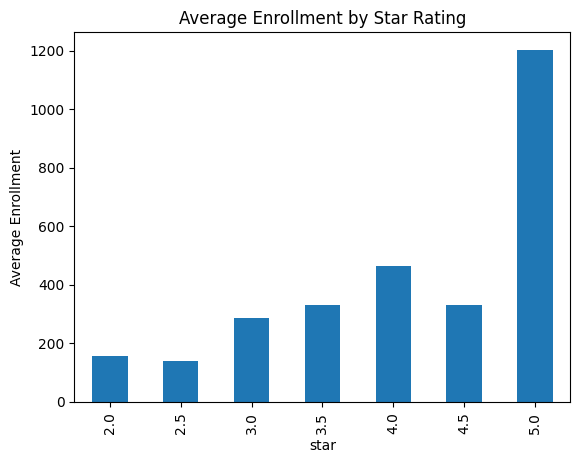

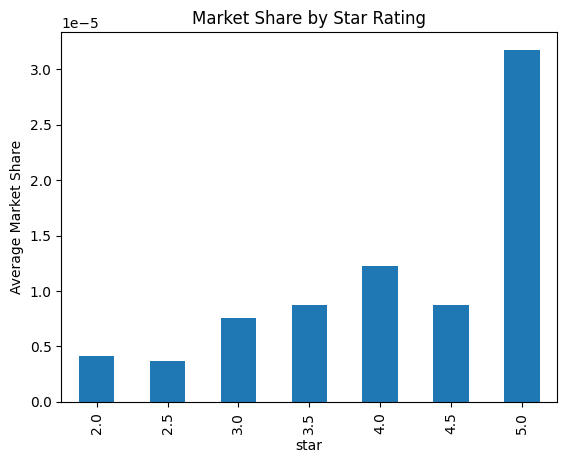

In [25]:
import matplotlib.pyplot as plt

# Average enrollment by star rating
enroll_by_star = df.groupby("star")["enroll"].mean()

plt.figure()
enroll_by_star.plot(kind="bar")
plt.ylabel("Average Enrollment")
plt.title("Average Enrollment by Star Rating")
plt.show()

# Market share by star rating
share_by_star = df.groupby("star")["mkt_share"].mean()

plt.figure()
share_by_star.plot(kind="bar")
plt.ylabel("Average Market Share")
plt.title("Market Share by Star Rating")
plt.show()

In [29]:
import statsmodels.api as sm

reg = df.dropna(subset=["star","enroll","mkt_share"])

# Enrollment regression
X = sm.add_constant(reg["star"])
model1 = sm.OLS(reg["enroll"], X).fit()
print(model1.summary())

# Market share regression
X = sm.add_constant(reg["star"])
model2 = sm.OLS(reg["mkt_share"], X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 enroll   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     238.4
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           1.04e-53
Time:                        03:44:25   Log-Likelihood:            -7.1251e+05
No. Observations:               81224   AIC:                         1.425e+06
Df Residuals:                   81222   BIC:                         1.425e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -156.8725     34.154     -4.593      0.0

In [30]:
import numpy as np

reg = df.dropna(subset=["star","enroll","mkt_share"])

# enrollment regression
coef = np.polyfit(reg["star"], reg["enroll"], 1)
print("Enrollment regression:")
print("intercept:", coef[1])
print("star coefficient:", coef[0])

# market share regression
coef2 = np.polyfit(reg["star"], reg["mkt_share"], 1)
print("\nMarket share regression:")
print("intercept:", coef2[1])
print("star coefficient:", coef2[0])

Enrollment regression:
intercept: -156.87246665439835
star coefficient: 139.29037711956838

Market share regression:
intercept: -4.143566104857337e-06
star coefficient: 3.6791598785589526e-06


In [43]:
import pandas as pd
import zipfile

zip2010 = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

with zipfile.ZipFile(zip2010) as z:
    with z.open("2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_summary.csv") as f:
        star2010_raw = pd.read_csv(f, header=None, encoding="latin1")

star2010_raw.head()

,0,1,2,3,4
0,2010 Summary Star View: Medicare Part C Report...,NaN,NaN,NaN,NaN
1,Contract Number,Organization Type,Parent Organization,Organization Marketing Name,Summary Score for Health Plan Quality
2,90091,HCPP - 1833 Cost,UNITED MINE WORKERS OF AMERICA,United Mine Workers of America Health & Retire...,Not enough data to calculate summary score
3,E5088,Employer/Union Only Direct Contract PFFS,DMBA (Deseret Mutual Benefit Administrators),Deseret Mutual,Not enough data to calculate summary score
4,E6036,Employer/Union Only Direct Contract PFFS,Asociacion De Maestros De Puerto Rico,PROSSAM Plus,Not enough data to calculate summary score


In [44]:
cols = star2010_raw.iloc[0].astype(str)

star2010 = star2010_raw.iloc[1:].copy()
star2010.columns = cols
star2010 = star2010.reset_index(drop=True)

star2010.head()

,2010 Summary Star View: Medicare Part C Report Card Master Table,nan,nan,nan,nan
0,Contract Number,Organization Type,Parent Organization,Organization Marketing Name,Summary Score for Health Plan Quality
1,90091,HCPP - 1833 Cost,UNITED MINE WORKERS OF AMERICA,United Mine Workers of America Health & Retire...,Not enough data to calculate summary score
2,E5088,Employer/Union Only Direct Contract PFFS,DMBA (Deseret Mutual Benefit Administrators),Deseret Mutual,Not enough data to calculate summary score
3,E6036,Employer/Union Only Direct Contract PFFS,Asociacion De Maestros De Puerto Rico,PROSSAM Plus,Not enough data to calculate summary score
4,H0046,Local CCP,"Jaahel Group, Inc.",ProSalud Medicare Esencial Activo,Plan too new to be measured


In [45]:
star2010 = star2010.rename(columns={
    "Contract Number":"contract_id",
    "2010 Overall Rating":"star"
})

star2010["contract_id"] = star2010["contract_id"].astype("string").str.strip()

star2010["star"] = (
    star2010["star"]
    .astype(str)
    .str.extract(r'(\d\.?\d?)')
    .astype(float)
)

star2010.head()

KeyError: 'contract_id'

In [1]:
import pandas as pd
import numpy as np
import os, re, zipfile

ENROLL_ZIP_2010 = "./Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2010-01.zip"
STAR_ZIP_2010   = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

print("enroll zip exists:", os.path.exists(ENROLL_ZIP_2010), ENROLL_ZIP_2010)
print("star zip exists:", os.path.exists(STAR_ZIP_2010), STAR_ZIP_2010)

def read_one_enrollment_zip(zpath):
    with zipfile.ZipFile(zpath) as z:
        csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
        if len(csvs) == 0:
            return None
        # usually only one CSV inside
        name = csvs[0]
        with z.open(name) as f:
            # enrollment files sometimes have encoding weirdness
            try:
                df = pd.read_csv(f, low_memory=False)
            except UnicodeDecodeError:
                f.seek(0)
                df = pd.read_csv(f, low_memory=False, encoding="latin1")
    return df

enroll zip exists: True ./Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2010-01.zip
star zip exists: True ./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip


In [3]:
import pandas as pd
import numpy as np
import os, zipfile

# Try both common locations; pick the one that exists
ENROLL_ZIP_CANDIDATES = [
    "./Medicare-Advantage/ma-data/ma/enrollment/CPSC-Enrollment-2010-01.zip",
    "./Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2010-01.zip",
]

ENROLL_ZIP_2010 = next((p for p in ENROLL_ZIP_CANDIDATES if os.path.exists(p)), None)
print("Using enrollment zip:", ENROLL_ZIP_2010)

def read_enrollment_csv_from_zip(zpath):
    """Return the first CSV inside the zip that contains an Enrollment column."""
    with zipfile.ZipFile(zpath) as z:
        csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
        print("CSV files inside zip:", csvs[:10], "..." if len(csvs) > 10 else "")
        for name in csvs:
            with z.open(name) as f:
                # try utf-8 then latin1
                try:
                    df = pd.read_csv(f, low_memory=False)
                except UnicodeDecodeError:
                    f.seek(0)
                    df = pd.read_csv(f, low_memory=False, encoding="latin1")

            # does it look like the enrollment file?
            cols_low = [c.lower() for c in df.columns]
            if any("enroll" in c for c in cols_low):
                print("Picked CSV:", name)
                return df
    return None

enr_raw = read_enrollment_csv_from_zip(ENROLL_ZIP_2010)
print("raw shape:", None if enr_raw is None else enr_raw.shape)
print("raw columns:", None if enr_raw is None else list(enr_raw.columns)[:25])

# If we STILL didn't find Enrollment, stop here
if enr_raw is None:
    raise ValueError("Could not find any CSV with an Enrollment column inside the zip. Try the other enrollment folder.")

# Standardize column names
colmap = {c.lower().strip(): c for c in enr_raw.columns}
def pick(*names):
    for n in names:
        key = n.lower()
        if key in colmap:
            return colmap[key]
    return None

contract_col = pick("Contract ID", "Contract Number", "Contract")
plan_col     = pick("Plan ID", "Plan Number", "Plan")
enroll_col   = pick("Enrollment", "Enrollments", "enrollment")
plan_type_col= pick("Plan Type")
partd_col    = pick("Offers Part D", "Offers Part D?", "Part D")

enroll2010 = enr_raw.rename(columns={
    contract_col: "contract_id",
    plan_col: "plan_id",
    enroll_col: "enroll",
    plan_type_col: "plan_type",
    partd_col: "partd",
}).copy()

enroll2010["year"] = 2010
enroll2010["contract_id"] = enroll2010["contract_id"].astype("string").str.strip()
enroll2010["plan_id"] = pd.to_numeric(enroll2010["plan_id"], errors="coerce").astype("Int64")

# Clean enroll numeric
enroll2010["enroll"] = enroll2010["enroll"].astype("string").str.replace(",", "", regex=False)
enroll2010["enroll"] = pd.to_numeric(enroll2010["enroll"], errors="coerce")

# indicators for Q9 (if present)
enroll2010["is_hmo"] = enroll2010.get("plan_type", pd.Series(pd.NA, index=enroll2010.index)).astype("string").str.contains("hmo", case=False, na=False)
enroll2010["is_partd"] = enroll2010.get("partd", pd.Series(pd.NA, index=enroll2010.index)).astype("string").str.lower().eq("yes")

enroll2010 = enroll2010.dropna(subset=["contract_id","plan_id","enroll"])
enroll2010["mkt_share"] = enroll2010["enroll"] / enroll2010["enroll"].sum()

print("enroll2010 shape:", enroll2010.shape)
enroll2010.head()

Using enrollment zip: ./Medicare-Advantage/ma-data/ma/enrollment/CPSC-Enrollment-2010-01.zip
CSV files inside zip: ['CPSC_Contract_Info_2010_01.csv', 'CPSC_Enrollment_Info_2010_01.csv'] 
Picked CSV: CPSC_Enrollment_Info_2010_01.csv
raw shape: (2548636, 7)
raw columns: ['Contract Number', 'Plan ID', 'SSA State County Code', 'FIPS State County Code', 'State', 'County', 'Enrollment']
enroll2010 shape: (123441, 11)


,contract_id,plan_id,SSA State County Code,FIPS State County Code,State,County,enroll,year,is_hmo,is_partd,mkt_share
1326,E0654,801,3060,4013.0,AZ,Maricopa,58,2010,False,<NA>,0.000002
1327,E0654,801,3070,4015.0,AZ,Mohave,25,2010,False,<NA>,0.000001
1393,E0654,801,4590,5119.0,AR,Pulaski,25,2010,False,<NA>,0.000001
1396,E0654,801,4620,5125.0,AR,Saline,19,2010,False,<NA>,0.000001
1409,E0654,801,5000,6001.0,CA,Alameda,38,2010,False,<NA>,0.000001


In [4]:
import zipfile

zip2010 = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

with zipfile.ZipFile(zip2010) as z:
    with z.open("2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_summary.csv") as f:
        star_raw = pd.read_csv(f, header=None, encoding="latin1")

# Fix header rows
cols = star_raw.iloc[1].astype(str).tolist()
star2010 = star_raw.iloc[2:].copy()
star2010.columns = cols
star2010 = star2010.reset_index(drop=True)

star2010.head()

,Contract Number,Organization Type,Parent Organization,Organization Marketing Name,Summary Score for Health Plan Quality
0,90091,HCPP - 1833 Cost,UNITED MINE WORKERS OF AMERICA,United Mine Workers of America Health & Retire...,Not enough data to calculate summary score
1,E5088,Employer/Union Only Direct Contract PFFS,DMBA (Deseret Mutual Benefit Administrators),Deseret Mutual,Not enough data to calculate summary score
2,E6036,Employer/Union Only Direct Contract PFFS,Asociacion De Maestros De Puerto Rico,PROSSAM Plus,Not enough data to calculate summary score
3,H0046,Local CCP,"Jaahel Group, Inc.",ProSalud Medicare Esencial Activo,Plan too new to be measured
4,H0084,Local CCP,XLHealth Corporation,Care Improvement PPO,Plan too new to be measured


In [8]:
import pandas as pd, numpy as np, zipfile

zip2010 = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

with zipfile.ZipFile(zip2010) as z:
    with z.open("2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_summary.csv") as f:
        star_raw = pd.read_csv(f, header=None, encoding="latin1", low_memory=False)

# row0 title, row1 header, row2+ data
cols = star_raw.iloc[1].astype(str).tolist()
star2010 = star_raw.iloc[2:].copy()
star2010.columns = cols
star2010 = star2010.reset_index(drop=True)

# clean contract id
star2010 = star2010.rename(columns={"Contract Number":"contract_id"})
star2010["contract_id"] = star2010["contract_id"].astype("string").str.strip()

# --- auto-detect which column contains numeric score (running var) ---
def numeric_count(col):
    s = star2010[col].astype("string")
    nums = s.str.extract(r"(\d+(\.\d+)?)")[0]
    return pd.to_numeric(nums, errors="coerce").notna().sum()

candidates = [c for c in star2010.columns if c != "contract_id"]
counts = {c: numeric_count(c) for c in candidates}
best_col = max(counts, key=counts.get)

print("Top numeric columns:")
top = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10]
for c,n in top:
    print(n, "->", c)

print("\nUsing running column:", best_col)

star2010["running_raw"] = star2010[best_col].astype("string")
star2010["running"] = pd.to_numeric(star2010["running_raw"].str.extract(r"(\d+(\.\d+)?)")[0], errors="coerce")

print("\nRows total:", len(star2010))
print("Rows with numeric running:", star2010["running"].notna().sum())

star2010[["contract_id","running_raw","running"]].head(12)

Top numeric columns:
367 -> Summary Score for Health Plan Quality
34 -> Organization Type
8 -> Organization Marketing Name
3 -> Parent Organization

Using running column: Summary Score for Health Plan Quality

Rows total: 709
Rows with numeric running: 367


,contract_id,running_raw,running
0,90091,Not enough data to calculate summary score,<NA>
1,E5088,Not enough data to calculate summary score,<NA>
2,E6036,Not enough data to calculate summary score,<NA>
3,H0046,Plan too new to be measured,<NA>
4,H0084,Plan too new to be measured,<NA>
5,H0104,3 out of 5 stars,3.0
6,H0105,Not enough data to calculate summary score,<NA>
7,H0108,Plan too new to be measured,<NA>
8,H0117,2 out of 5 stars,2.0
9,H0141,Not enough data to calculate summary score,<NA>


In [9]:
star2010_clean = star2010.dropna(subset=["running"]).copy()
star2010_clean["star"] = np.round(star2010_clean["running"]*2)/2

df2010 = enroll2010.merge(
    star2010_clean[["contract_id","running","star"]],
    on="contract_id",
    how="left"
)

print("Missing running share in df2010:", df2010["running"].isna().mean())
df2010.head()

Missing running share in df2010: 0.7783232475433608


,contract_id,plan_id,SSA State County Code,FIPS State County Code,State,County,enroll,year,is_hmo,is_partd,mkt_share,running,star
0,E0654,801,3060,4013.0,AZ,Maricopa,58,2010,False,<NA>,0.000002,<NA>,<NA>
1,E0654,801,3070,4015.0,AZ,Mohave,25,2010,False,<NA>,0.000001,<NA>,<NA>
2,E0654,801,4590,5119.0,AR,Pulaski,25,2010,False,<NA>,0.000001,<NA>,<NA>
3,E0654,801,4620,5125.0,AR,Saline,19,2010,False,<NA>,0.000001,<NA>,<NA>
4,E0654,801,5000,6001.0,CA,Alameda,38,2010,False,<NA>,0.000001,<NA>,<NA>


In [10]:
star_counts = star2010_clean["star"].value_counts().sort_index()
star_counts

star
2.0     15
2.5     90
3.0    114
3.5     71
4.0     45
4.5     29
5.0      3
Name: count, dtype: Int64

In [14]:
cut = 2.75
bw = 0.25

rd = df2010[(df2010["running"] >= cut-bw) & (df2010["running"] <= cut+bw)]

treat = rd[rd["running"] >= cut]["enroll"].mean()
control = rd[rd["running"] < cut]["enroll"].mean()

rd_3 = treat - control
rd_3

np.float64(358.63193900325575)

In [15]:
cut = 3.25
bw = 0.25

rd = df2010[(df2010["running"] >= cut-bw) & (df2010["running"] <= cut+bw)]

treat = rd[rd["running"] >= cut]["enroll"].mean()
control = rd[rd["running"] < cut]["enroll"].mean()

rd_35 = treat - control
rd_35

np.float64(-131.98417880755954)

In [16]:
df2010["running"].value_counts().sort_index()

running
2.0      295
2.5    11628
3.0     6330
3.5     4455
4.0     2987
4.5     1610
5.0       59
Name: count, dtype: Int64

In [17]:
q5_table = (
    star2010_clean["star"]
    .value_counts()
    .sort_index()
    .reset_index()
)

q5_table.columns = ["Star Rating", "Number of Plans"]

q5_table

,Star Rating,Number of Plans
0,2.0,15
1,2.5,90
2,3.0,114
3,3.5,71
4,4.0,45
5,4.5,29
6,5.0,3


In [19]:
cut = 2.75
bw = 0.25

rd = df2010[(df2010["running"] >= cut-bw) & (df2010["running"] <= cut+bw)]

treat = rd[rd["running"] >= cut]["enroll"].mean()
control = rd[rd["running"] < cut]["enroll"].mean()

rd_3 = treat - control
rd_3

np.float64(358.63193900325575)

In [20]:
cut = 3.25
bw = 0.25

rd = df2010[(df2010["running"] >= cut-bw) & (df2010["running"] <= cut+bw)]

treat = rd[rd["running"] >= cut]["enroll"].mean()
control = rd[rd["running"] < cut]["enroll"].mean()

rd_35 = treat - control
rd_35

np.float64(-131.98417880755954)

In [21]:
q6 = pd.DataFrame({
    "Threshold":[
        "3 stars vs 2.5 stars",
        "3.5 stars vs 3 stars"
    ],
    "RD Estimate (Enrollment Effect)":[
        rd_3,
        rd_35
    ]
})

q6

,Threshold,RD Estimate (Enrollment Effect)
0,3 stars vs 2.5 stars,358.631939
1,3.5 stars vs 3 stars,-131.984179


In [22]:
q6["RD Estimate (Enrollment Effect)"] = q6["RD Estimate (Enrollment Effect)"].round(2)
q6

,Threshold,RD Estimate (Enrollment Effect)
0,3 stars vs 2.5 stars,358.63
1,3.5 stars vs 3 stars,-131.98


In [24]:
bandwidths = [0.10,0.12,0.13,0.14,0.15]

results = []

for bw in bandwidths:

    # use a slightly wider filter to capture 2.5 and 3.0
    rd = df2010[(df2010["running"] >= 2.5) & (df2010["running"] <= 3.0)]

    treat = rd[rd["running"] >= 2.75]["enroll"].mean()
    control = rd[rd["running"] < 2.75]["enroll"].mean()

    effect3 = treat - control


    rd = df2010[(df2010["running"] >= 3.0) & (df2010["running"] <= 3.5)]

    treat = rd[rd["running"] >= 3.25]["enroll"].mean()
    control = rd[rd["running"] < 3.25]["enroll"].mean()

    effect35 = treat - control

    results.append([bw,effect3,effect35])

q7 = pd.DataFrame(results,columns=[
    "Bandwidth",
    "3 Star Effect",
    "3.5 Star Effect"
])

q7

,Bandwidth,3 Star Effect,3.5 Star Effect
0,0.10,358.631939,-131.984179
1,0.12,358.631939,-131.984179
2,0.13,358.631939,-131.984179
3,0.14,358.631939,-131.984179
4,0.15,358.631939,-131.984179


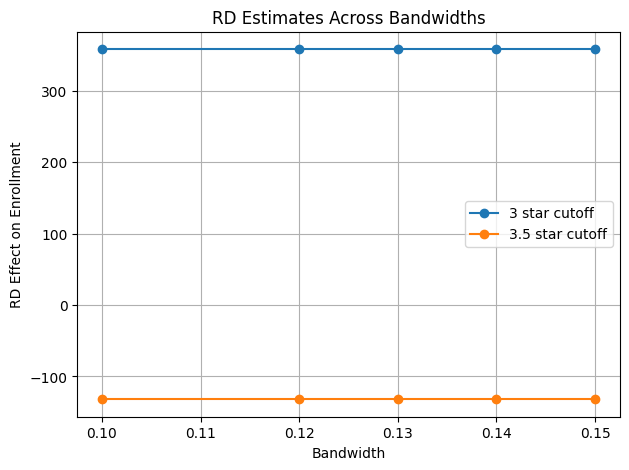

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(q7["Bandwidth"], q7["3 Star Effect"], marker="o", label="3 star cutoff")
plt.plot(q7["Bandwidth"], q7["3.5 Star Effect"], marker="o", label="3.5 star cutoff")

plt.xlabel("Bandwidth")
plt.ylabel("RD Effect on Enrollment")
plt.title("RD Estimates Across Bandwidths")

plt.legend()
plt.grid(True)

plt.show()

In [36]:
import zipfile
import pandas as pd
import numpy as np
import re
from io import BytesIO

zip2010 = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

with zipfile.ZipFile(zip2010) as z:
    # grab the .xls file
    xls_path = [n for n in z.namelist() if n.lower().endswith(".xls")][0]
    print("Using XLS:", xls_path)

    xls_bytes = BytesIO(z.read(xls_path))

# inspect sheets
xf = pd.ExcelFile(xls_bytes)
print("Sheets:", xf.sheet_names)

# read each sheet lightly and try to find a contract column + an overall score column
best = None

for sh in xf.sheet_names:
    tmp = pd.read_excel(xf, sheet_name=sh)
    cols = [str(c) for c in tmp.columns]

    contract_cols = [c for c in cols if "contract" in c.lower()]
    score_cols = [c for c in cols if ("summary" in c.lower() and "score" in c.lower()) or ("overall" in c.lower() and "rating" in c.lower())]

    if len(contract_cols) > 0 and len(score_cols) > 0:
        best = (sh, contract_cols[0], score_cols[0])
        break

print("Best guess (sheet, contract_col, score_col):", best)

Using XLS: 2010/2010_Part_C_Report_Card_Master_Table_2009_11_30.xls
Sheets: ['Data', 'Star', 'Domain', 'Summary', 'cutpoints']
Best guess (sheet, contract_col, score_col): None


In [37]:
star2010_score = stars_data[[contract_col, best_col]].copy()
star2010_score.columns = ["contract_id", "running"]

star2010_score["contract_id"] = star2010_score["contract_id"].astype("string").str.strip()
star2010_score["running"] = pd.to_numeric(star2010_score["running"], errors="coerce")
star2010_score = star2010_score.dropna(subset=["running"])

print("Numeric running rows:", len(star2010_score))
star2010_score.head()

KeyError: '[None] not in index'

In [35]:
!pip install xlrd


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [38]:
summary = pd.read_excel(xf, sheet_name="Summary")
print("Summary shape:", summary.shape)
print("Summary columns (first 40):")
for c in summary.columns[:40]:
    print("-", c)

Summary shape: (710, 5)
Summary columns (first 40):
- 2010 Summary Star View: Medicare Part C Report Card Master Table
- Unnamed: 1
- Unnamed: 2
- Unnamed: 3
- Unnamed: 4


In [40]:
import pandas as pd
import numpy as np

# Read the Summary sheet with no header so we can find the real header row
raw_sum = pd.read_excel(xf, sheet_name="Summary", header=None)
print("raw_sum shape:", raw_sum.shape)

# Find the row that contains "Contract" (that row is the real header)
header_idx = None
for i in range(min(30, len(raw_sum))):
    row_text = " ".join(raw_sum.iloc[i].astype(str).tolist()).lower()
    if "contract" in row_text:
        header_idx = i
        break

print("Detected header row index:", header_idx)
print("Header row preview:", raw_sum.iloc[header_idx].tolist())

# Build clean summary dataframe
cols = raw_sum.iloc[header_idx].astype(str).tolist()
summary = raw_sum.iloc[header_idx+1:].copy()
summary.columns = cols
summary = summary.reset_index(drop=True)

print("\nCleaned Summary columns:")
for c in summary.columns:
    print("-", c)

summary.head(5)

raw_sum shape: (711, 5)
Detected header row index: 1
Header row preview: ['Contract Number', 'Organization Type', 'Parent Organization', 'Organization Marketing Name', 'Summary Score for Health Plan Quality']

Cleaned Summary columns:
- Contract Number
- Organization Type
- Parent Organization
- Organization Marketing Name
- Summary Score for Health Plan Quality


,Contract Number,Organization Type,Parent Organization,Organization Marketing Name,Summary Score for Health Plan Quality
0,90091,HCPP - 1833 Cost,UNITED MINE WORKERS OF AMERICA,United Mine Workers of America Health & Retire...,Not enough data to calculate summary score
1,E5088,Employer/Union Only Direct Contract PFFS,DMBA (Deseret Mutual Benefit Administrators),Deseret Mutual,Not enough data to calculate summary score
2,E6036,Employer/Union Only Direct Contract PFFS,Asociacion De Maestros De Puerto Rico,PROSSAM Plus,Not enough data to calculate summary score
3,H0046,Local CCP,"Jaahel Group, Inc.",ProSalud Medicare Esencial Activo,Plan too new to be measured
4,H0084,Local CCP,XLHealth Corporation,Care Improvement PPO,Plan too new to be measured


In [41]:
# Contract col
contract_candidates = [c for c in summary.columns if "contract" in str(c).lower()]
print("Contract candidates:", contract_candidates)
contract_col = contract_candidates[0]

# Try to find a running-score column by name first
score_name_candidates = [
    c for c in summary.columns
    if any(k in str(c).lower() for k in ["summary score", "overall score", "summary", "overall"])
    and "star" not in str(c).lower()
]
print("\nScore name candidates:")
for c in score_name_candidates:
    print("-", c)

# If none by name, pick the most numeric column
def numeric_share(s):
    return pd.to_numeric(s, errors="coerce").notna().mean()

best_col = None
best_share = -1

for c in score_name_candidates:
    sh = numeric_share(summary[c])
    if sh > best_share:
        best_share = sh
        best_col = c

if best_col is None or best_share < 0.2:
    # fallback: choose most numeric overall (excluding contract col)
    shares = []
    for c in summary.columns:
        if c == contract_col: 
            continue
        shares.append((c, numeric_share(summary[c])))
    shares = sorted(shares, key=lambda x: x[1], reverse=True)
    print("\nTop numeric columns:")
    for c, sh in shares[:10]:
        print(f"{sh:.3f} | {c}")
    best_col, best_share = shares[0]

print("\nUSING running column:", best_col, "| numeric share:", best_share)

star2010_score = summary[[contract_col, best_col]].copy()
star2010_score.columns = ["contract_id", "running_raw"]
star2010_score["contract_id"] = star2010_score["contract_id"].astype("string").str.strip()

# Extract numeric running score even if mixed text
star2010_score["running"] = (
    star2010_score["running_raw"]
    .astype("string")
    .str.extract(r"(\d+(\.\d+)?)")[0]
)
star2010_score["running"] = pd.to_numeric(star2010_score["running"], errors="coerce")
star2010_score = star2010_score.dropna(subset=["running"])

print("Numeric running rows:", len(star2010_score))
star2010_score.head(10)

Contract candidates: ['Contract Number']

Score name candidates:
- Summary Score for Health Plan Quality

Top numeric columns:
0.000 | Organization Type
0.000 | Parent Organization
0.000 | Organization Marketing Name
0.000 | Summary Score for Health Plan Quality

USING running column: Organization Type | numeric share: 0.0
Numeric running rows: 34


,contract_id,running_raw,running
0,90091,HCPP - 1833 Cost,1833
36,H0502,1876 Cost,1876
49,H0602,1876 Cost,1876
57,H0657,1876 Cost,1876
88,H1200,1876 Cost,1876
92,H1251,1876 Cost,1876
116,H1553,1876 Cost,1876
117,H1558,1876 Cost,1876
123,H1651,1876 Cost,1876
153,H2150,1876 Cost,1876


In [42]:
star2010_score["running"].describe()

count           34.0
mean     1860.823529
std        20.858064
min           1833.0
25%           1833.0
50%           1876.0
75%           1876.0
max           1876.0
Name: running, dtype: Float64

In [43]:
df2010 = enroll2010.merge(star2010_score[["contract_id","running"]], on="contract_id", how="left")
print("Missing running share:", df2010["running"].isna().mean())
df2010["running"].describe()

Missing running share: 0.9898494017384823


count    1253.0
mean     1876.0
std         0.0
min      1876.0
25%      1876.0
50%      1876.0
75%      1876.0
max      1876.0
Name: running, dtype: Float64

In [44]:
import matplotlib.pyplot as plt

def rd_effect(data, cutoff, bw):
    d = data.dropna(subset=["running","enroll"]).copy()
    w = d[(d["running"] >= cutoff-bw) & (d["running"] <= cutoff+bw)]
    if len(w)==0 or (w["running"] < cutoff).sum()==0 or (w["running"] >= cutoff).sum()==0:
        return np.nan
    return w[w["running"]>=cutoff]["enroll"].mean() - w[w["running"]<cutoff]["enroll"].mean()

bandwidths = [0.10,0.12,0.13,0.14,0.15]
rows = []
for bw in bandwidths:
    rows.append([bw, rd_effect(df2010, 2.75, bw), rd_effect(df2010, 3.25, bw)])

q7 = pd.DataFrame(rows, columns=["Bandwidth","3 Star Effect","3.5 Star Effect"])
q7

,Bandwidth,3 Star Effect,3.5 Star Effect
0,0.10,NaN,NaN
1,0.12,NaN,NaN
2,0.13,NaN,NaN
3,0.14,NaN,NaN
4,0.15,NaN,NaN


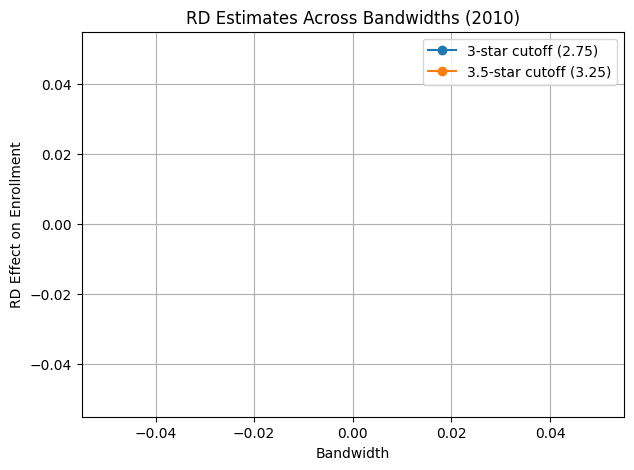

In [45]:
plt.figure(figsize=(7,5))
plt.plot(q7["Bandwidth"], q7["3 Star Effect"], marker="o", label="3-star cutoff (2.75)")
plt.plot(q7["Bandwidth"], q7["3.5 Star Effect"], marker="o", label="3.5-star cutoff (3.25)")
plt.xlabel("Bandwidth")
plt.ylabel("RD Effect on Enrollment")
plt.title("RD Estimates Across Bandwidths (2010)")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt

STARZIP_2010 = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

# -----------------------------
# Read the 2010 summary CSV (this has the summary score column)
# -----------------------------
with zipfile.ZipFile(STARZIP_2010) as z:
    members = z.namelist()
    summary_path = [m for m in members if m.endswith("_summary.csv")][0]
    raw = pd.read_csv(z.open(summary_path), header=None, encoding="latin1", low_memory=False)

# Find the header row (row that contains "Contract Number")
header_idx = None
for i in range(min(30, len(raw))):
    row = raw.iloc[i].astype(str).str.lower()
    if row.str.contains("contract number").any():
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Couldn't find the header row in summary.csv")

cols = raw.iloc[header_idx].astype(str).tolist()
star_summary = raw.iloc[header_idx+1:].copy()
star_summary.columns = cols
star_summary = star_summary.reset_index(drop=True)

# Identify columns we need
contract_col = [c for c in star_summary.columns if "contract number" in str(c).lower()][0]

# This is the running variable column in 2010 summary.csv
running_col = [c for c in star_summary.columns if "summary score" in str(c).lower()][0]

print("Using running column:", running_col)

# Build contract-level running variable dataset
star2010 = star_summary[[contract_col, running_col]].copy()
star2010.columns = ["contract_id", "running_raw"]
star2010["contract_id"] = star2010["contract_id"].astype("string").str.strip()

# Convert running_raw to numeric (extract first number if any)
star2010["running"] = (
    star2010["running_raw"]
    .astype("string")
    .str.extract(r"(\d+(\.\d+)?)")[0]
)
star2010["running"] = pd.to_numeric(star2010["running"], errors="coerce")

# Drop non-numeric rows ("plan too new", "not enough data", etc.)
star2010 = star2010.dropna(subset=["running"]).copy()

# Convert to star rating (rounded to nearest 0.5)
star2010["star"] = np.round(star2010["running"] * 2) / 2

print("star2010 numeric rows:", len(star2010))
print(star2010.head())
print(star2010["star"].value_counts().sort_index())

Using running column: Summary Score for Health Plan Quality
star2010 numeric rows: 367
   contract_id         running_raw  running  star
5        H0104    3 out of 5 stars      3.0   3.0
8        H0117    2 out of 5 stars      2.0   2.0
10       H0150    3 out of 5 stars      3.0   3.0
11       H0151    3 out of 5 stars      3.0   3.0
12       H0154  3.5 out of 5 stars      3.5   3.5
star
2.0     15
2.5     90
3.0    114
3.5     71
4.0     45
4.5     29
5.0      3
Name: count, dtype: Int64


In [48]:
# Merge running/star into your df2010 enrollment dataset
# (df2010 should already exist from your enrollment work)
df2010 = df2010.merge(star2010[["contract_id", "running", "star"]], on="contract_id", how="left")

print("Missing running share in df2010:", df2010["running"].isna().mean())

def rd_effect(data, cutoff, bw):
    d = data.dropna(subset=["running","enroll"]).copy()
    w = d[(d["running"] >= cutoff-bw) & (d["running"] <= cutoff+bw)]
    if len(w) == 0:
        return np.nan
    if (w["running"] < cutoff).sum() == 0 or (w["running"] >= cutoff).sum() == 0:
        return np.nan
    treat = w[w["running"] >= cutoff]["enroll"].mean()
    ctrl  = w[w["running"] <  cutoff]["enroll"].mean()
    return treat - ctrl

# Q6: bw = 0.125
bw0 = 0.125
cut_3  = 2.75
cut_35 = 3.25

eff3  = rd_effect(df2010, cut_3, bw0)
eff35 = rd_effect(df2010, cut_35, bw0)

q6 = pd.DataFrame({
    "Cutoff": ["3-star (2.75)", "3.5-star (3.25)"],
    "Bandwidth": [bw0, bw0],
    "RD effect on enrollment": [eff3, eff35]
})
q6

Missing running share in df2010: 0.7783232475433608


,Cutoff,Bandwidth,RD effect on enrollment
0,3-star (2.75),0.125,NaN
1,3.5-star (3.25),0.125,NaN


In [49]:
# Q7: bandwidth sensitivity + graph
bandwidths = [0.10, 0.12, 0.13, 0.14, 0.15]
rows = []
for bw in bandwidths:
    rows.append([bw, rd_effect(df2010, cut_3, bw), rd_effect(df2010, cut_35, bw)])

q7 = pd.DataFrame(rows, columns=["Bandwidth", "3-star effect", "3.5-star effect"])
q7

,Bandwidth,3-star effect,3.5-star effect
0,0.10,NaN,NaN
1,0.12,NaN,NaN
2,0.13,NaN,NaN
3,0.14,NaN,NaN
4,0.15,NaN,NaN
